# Zinc-Ingot and Warehouse-Receipt Data Audit

This notebook reads raw data and never writes to `data/raw`. The physical scope accepts cash and cash-matching contracts. Positive activity requires `Quantity > 0` and `Price > 0` in the physical market and `TradesVolume > 0` in the certificate market. Zinc dust is excluded from the ingot-grade analysis.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

def find_project_dir() -> Path:
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        direct = base / "data/raw/physical/zinc_physical_raw.csv"
        nested = base / "commodity/zinc/data/raw/physical/zinc_physical_raw.csv"
        if direct.exists():
            return base
        if nested.exists():
            return base / "commodity/zinc"
    raise FileNotFoundError("Could not locate commodity/zinc from the current directory")

PROJECT_DIR = find_project_dir()
PHYSICAL_PATH = PROJECT_DIR / "data/raw/physical/zinc_physical_raw.csv"
CERTIFICATE_PATH = PROJECT_DIR / "data/raw/certificate/zinc_certificate_raw.csv"

physical_raw = pd.read_csv(PHYSICAL_PATH, encoding="utf-8-sig", low_memory=False)
certificate_raw = pd.read_csv(CERTIFICATE_PATH, encoding="utf-8-sig", low_memory=False)

print(f"Project: {PROJECT_DIR}")
print(f"Physical raw: {physical_raw.shape[0]:,} rows × {physical_raw.shape[1]} columns")
print(f"Certificate raw: {certificate_raw.shape[0]:,} rows × {certificate_raw.shape[1]} columns")

Project: C:\Work\commodity\zinc
Physical raw: 6,235 rows × 36 columns
Certificate raw: 256 rows × 32 columns


## Preparation and definition of positive transaction
A common Jalali date is constructed because the physical market uses `date` while the certificate uses `PersianDate`. Ingot grade is extracted from `GoodsName` and normalized to two decimals, such as `99.97`.

In [2]:
def normalize_fa(value: object) -> str:
    return str(value or "").replace("ي", "ی").replace("ك", "ک").strip()

def normalize_jalali_date(value: object) -> str | None:
    if pd.isna(value):
        return None
    parts = str(value).strip().replace("-", "/").split("/")
    if len(parts) != 3:
        return None
    try:
        year, month, day = map(int, parts)
    except ValueError:
        return None
    return f"{year:04d}/{month:02d}/{day:02d}"

def extract_zinc_grade(goods_name: object) -> str | None:
    name = normalize_fa(goods_name)
    if "شمش روی" not in name:
        return None
    match = re.search(r"(\d{2}(?:\.\d+)?)", name)
    return f"{float(match.group(1)):.2f}" if match else None

physical = physical_raw.copy()
certificate = certificate_raw.copy()

for column in ["Quantity", "Price", "TotalPrice"]:
    physical[column] = pd.to_numeric(physical[column], errors="coerce")
for column in ["TradesVolume", "TradesValue", "TodaySettlementPrice"]:
    certificate[column] = pd.to_numeric(certificate[column], errors="coerce")

physical["jalali_date"] = physical["date"].map(normalize_jalali_date)
certificate["jalali_date"] = certificate["PersianDate"].map(normalize_jalali_date)
physical["grade"] = physical["GoodsName"].map(extract_zinc_grade)

ALLOWED_CONTRACT_TYPES = {"نقدی", "نقدی (مچینگ)"}
physical["contract_type_normalized"] = physical["ContractType"].map(normalize_fa)
physical_trades = physical.loc[
    physical["contract_type_normalized"].isin(ALLOWED_CONTRACT_TYPES)
    & (physical["Quantity"] > 0)
    & (physical["Price"] > 0)
].copy()
ingot_trades = physical_trades.loc[physical_trades["grade"].notna()].copy()
certificate_trades = certificate.loc[certificate["TradesVolume"] > 0].copy()

assert set(physical_trades["contract_type_normalized"].unique()) <= ALLOWED_CONTRACT_TYPES
assert ingot_trades["GoodsName"].map(normalize_fa).str.contains("خاک روی", na=False).sum() == 0
assert certificate_trades["jalali_date"].notna().all()

print(f"Allowed physical contracts: {sorted(ALLOWED_CONTRACT_TYPES)}")
print(f"Positive physical rows (cash and cash-matching): {len(physical_trades):,}")
print(f"Positive zinc-ingot rows: {len(ingot_trades):,}")
print(f"Positive certificate days: {certificate_trades['jalali_date'].nunique():,}")

Allowed physical contracts: ['نقدی', 'نقدی (مچینگ)']
Positive physical rows (cash and cash-matching): 3,434
Positive zinc-ingot rows: 2,853
Positive certificate days: 184


## Overview of two markets and trading days
The first table shows the size and coverage of each market. The second table is the complete calendar of active days; So it can be seen that on any given date only the physical market, only the certificate, or both were active.

In [3]:
market_overview = pd.DataFrame([
    {
        "market": "physical — all zinc-related goods (cash + cash-matching)",
        "positive_trade_rows": len(physical_trades),
        "trading_days": physical_trades["jalali_date"].nunique(),
        "first_trade_day": physical_trades["jalali_date"].min(),
        "last_trade_day": physical_trades["jalali_date"].max(),
        "total_volume": physical_trades["Quantity"].sum(),
    },
    {
        "market": "physical — zinc ingot only (cash + cash-matching)",
        "positive_trade_rows": len(ingot_trades),
        "trading_days": ingot_trades["jalali_date"].nunique(),
        "first_trade_day": ingot_trades["jalali_date"].min(),
        "last_trade_day": ingot_trades["jalali_date"].max(),
        "total_volume": ingot_trades["Quantity"].sum(),
    },
    {
        "market": "zinc certificate",
        "positive_trade_rows": len(certificate_trades),
        "trading_days": certificate_trades["jalali_date"].nunique(),
        "first_trade_day": certificate_trades["jalali_date"].min(),
        "last_trade_day": certificate_trades["jalali_date"].max(),
        "total_volume": certificate_trades["TradesVolume"].sum(),
    },
]).set_index("market")
display(market_overview)

physical_all_days = set(physical_trades["jalali_date"].dropna())
physical_ingot_days = set(ingot_trades["jalali_date"].dropna())
certificate_days = set(certificate_trades["jalali_date"].dropna())
all_active_days = sorted(physical_all_days | certificate_days)

market_calendar = pd.DataFrame({"jalali_date": all_active_days})
market_calendar["physical_any_zinc_trade"] = market_calendar["jalali_date"].isin(physical_all_days)
market_calendar["physical_ingot_trade"] = market_calendar["jalali_date"].isin(physical_ingot_days)
market_calendar["certificate_trade"] = market_calendar["jalali_date"].isin(certificate_days)
market_calendar["both_ingot_and_certificate"] = (
    market_calendar["physical_ingot_trade"] & market_calendar["certificate_trade"]
)
display(market_calendar)

,positive_trade_rows,trading_days,first_trade_day,last_trade_day,total_volume
market,,,,,
physical — all zinc-related goods (cash + cash-matching),3434,756,1387/07/28,1405/05/18,4439918.0
physical — zinc ingot only (cash + cash-matching),2853,661,1387/07/28,1405/05/18,278418.0
zinc certificate,184,184,1404/07/28,1405/05/20,3926406.0


,jalali_date,physical_any_zinc_trade,physical_ingot_trade,certificate_trade,both_ingot_and_certificate
0,1387/07/28,True,True,False,False
1,1387/08/27,True,True,False,False
2,1387/09/25,True,True,False,False
3,1387/10/25,True,True,False,False
4,1387/11/30,True,True,False,False
...,...,...,...,...,...
876,1405/05/14,True,True,True,True
877,1405/05/17,False,False,True,False
878,1405/05/18,True,True,True,True
879,1405/05/19,False,False,True,False


In [4]:
# Monthly view of activity density and gaps in both markets
monthly_activity = (
    market_calendar.assign(jalali_month=lambda frame: frame["jalali_date"].str[:7])
    .groupby("jalali_month", as_index=False)
    .agg(
        physical_any_zinc_days=("physical_any_zinc_trade", "sum"),
        physical_ingot_days=("physical_ingot_trade", "sum"),
        certificate_days=("certificate_trade", "sum"),
        both_ingot_certificate_days=("both_ingot_and_certificate", "sum"),
    )
)
display(monthly_activity)

,jalali_month,physical_any_zinc_days,physical_ingot_days,certificate_days,both_ingot_certificate_days
0,1387/07,1,1,0,0
1,1387/08,1,1,0,0
2,1387/09,1,1,0,0
3,1387/10,1,1,0,0
4,1387/11,1,1,0,0
5,1388/01,2,2,0,0
6,1388/02,1,1,0,0
7,1388/03,1,1,0,0
8,1388/05,1,1,0,0
9,1388/07,1,1,0,0


## Positive trades and trading dates by ingot grade

`trade_rows` counts positive source rows and `trading_days` counts unique active dates. `trade_dates` preserves the exact activity calendar for each grade.


In [5]:
grade_activity = (
    ingot_trades.groupby("grade", as_index=False)
    .agg(
        trade_rows=("grade", "size"),
        trading_days=("jalali_date", "nunique"),
        first_trade_day=("jalali_date", "min"),
        last_trade_day=("jalali_date", "max"),
        total_quantity=("Quantity", "sum"),
        trade_dates=("jalali_date", lambda values: sorted(set(values.dropna()))),
    )
    .sort_values(["trading_days", "trade_rows"], ascending=False)
    .reset_index(drop=True)
)
display(grade_activity)

# Optional date-level view with one observation per row
grade_trade_dates = (
    ingot_trades[["grade", "jalali_date"]]
    .drop_duplicates()
    .sort_values(["grade", "jalali_date"])
    .reset_index(drop=True)
)
display(grade_trade_dates)

,grade,trade_rows,trading_days,first_trade_day,last_trade_day,total_quantity,trade_dates
0,99.97,856,397,1388/05/25,1405/05/18,71852.0,"[1388/05/25, 1388/07/27, 1388/08/27, 1388/09/0..."
1,99.98,924,396,1392/07/17,1405/05/11,83750.0,"[1392/07/17, 1393/05/14, 1393/05/15, 1393/06/0..."
2,99.96,567,270,1397/09/12,1405/05/18,85991.0,"[1397/09/12, 1397/11/28, 1397/12/04, 1397/12/0..."
3,99.95,277,188,1387/07/28,1405/05/14,23220.0,"[1387/07/28, 1387/08/27, 1387/10/25, 1388/01/2..."
4,99.99,148,99,1387/09/25,1405/05/18,6830.0,"[1387/09/25, 1387/11/30, 1388/02/28, 1388/03/2..."
5,99.94,37,36,1401/05/18,1405/05/18,3135.0,"[1401/05/18, 1401/06/13, 1401/09/27, 1401/11/0..."
6,99.93,33,28,1391/07/04,1405/03/24,2975.0,"[1391/07/04, 1391/07/11, 1391/07/18, 1391/08/0..."
7,99.92,7,7,1402/04/11,1405/03/24,475.0,"[1402/04/11, 1402/04/18, 1404/02/21, 1404/03/1..."
8,99.90,2,2,1404/04/08,1404/04/09,75.0,"[1404/04/08, 1404/04/09]"
9,99.60,1,1,1391/06/28,1391/06/28,40.0,[1391/06/28]


,grade,jalali_date
0,99.60,1391/06/28
1,99.90,1404/04/08
2,99.90,1404/04/09
3,99.91,1402/05/01
4,99.92,1402/04/11
...,...,...
1420,99.99,1405/04/21
1421,99.99,1405/04/28
1422,99.99,1405/05/05
1423,99.99,1405/05/11


## Certificate trading days and overlap with the target rate
To add `99.96` later, just change the value of `TARGET_GRADES` to `['99.97', '99.96']`. The overlap table shows the exact date of activity of each market and the summary of the number of common days.

In [6]:
certificate_trade_dates = (
    certificate_trades[["jalali_date", "DT", "ContractCode", "TradesVolume", "TodaySettlementPrice"]]
    .sort_values("jalali_date")
    .reset_index(drop=True)
)
display(certificate_trade_dates)

TARGET_GRADES = ["99.97"]  # later: ["99.97", "99.96"]

target_days_by_grade = {
    grade: set(ingot_trades.loc[ingot_trades["grade"].eq(grade), "jalali_date"].dropna())
    for grade in TARGET_GRADES
}
overlap_dates = sorted(certificate_days | set().union(*target_days_by_grade.values()))
overlap_calendar = pd.DataFrame({"jalali_date": overlap_dates})
overlap_calendar["certificate_trade"] = overlap_calendar["jalali_date"].isin(certificate_days)
for grade, grade_days in target_days_by_grade.items():
    overlap_calendar[f"ingot_{grade}_trade"] = overlap_calendar["jalali_date"].isin(grade_days)
    overlap_calendar[f"certificate_and_{grade}"] = (
        overlap_calendar["certificate_trade"] & overlap_calendar[f"ingot_{grade}_trade"]
    )

overlap_summary = pd.DataFrame([
    {
        "grade": grade,
        "ingot_trading_days": len(grade_days),
        "certificate_trading_days": len(certificate_days),
        "common_trading_days": len(grade_days & certificate_days),
        "common_dates": sorted(grade_days & certificate_days),
    }
    for grade, grade_days in target_days_by_grade.items()
])
display(overlap_summary)
display(overlap_calendar)

,jalali_date,DT,ContractCode,TradesVolume,TodaySettlementPrice
0,1404/07/28,2025-10-20T00:00:00,CD1ZNI0001,46284,3056494.0
1,1404/07/29,2025-10-21T00:00:00,CD1ZNI0001,5629,3056509.0
2,1404/07/30,2025-10-22T00:00:00,CD1ZNI0001,3217,3056500.0
3,1404/08/03,2025-10-25T00:00:00,CD1ZNI0001,4992,3062381.0
4,1404/08/04,2025-10-26T00:00:00,CD1ZNI0001,21045,3056519.0
5,1404/08/05,2025-10-27T00:00:00,CD1ZNI0001,6442,3040748.0
6,1404/08/06,2025-10-28T00:00:00,CD1ZNI0001,188,3052899.0
7,1404/08/07,2025-10-29T00:00:00,CD1ZNI0001,3044,3056503.0
8,1404/08/10,2025-11-01T00:00:00,CD1ZNI0001,3137,3056503.0
9,1404/08/11,2025-11-02T00:00:00,CD1ZNI0001,1074,3056501.0


,grade,ingot_trading_days,certificate_trading_days,common_trading_days,common_dates
0,99.97,397,184,36,"[1404/08/04, 1404/08/11, 1404/08/18, 1404/08/2..."


,jalali_date,certificate_trade,ingot_99.97_trade,certificate_and_99.97
0,1388/05/25,False,True,False
1,1388/07/27,False,True,False
2,1388/08/27,False,True,False
3,1388/09/04,False,True,False
4,1388/09/18,False,True,False
...,...,...,...,...
540,1405/05/14,True,False,False
541,1405/05/17,True,False,False
542,1405/05/18,True,True,True
543,1405/05/19,True,False,False


## The suppliers of every caliber and their share of transactions
The supplier name is taken from `ArzehKonandeh` and if empty, `ProducerName` is used. `trade_count_share_pct` is the company's share of the number of positive trade rows of the same grade and `quantity_share_pct` is its share of the traded volume of the same grade. These two criteria are intentionally separate.

In [7]:
supplier = ingot_trades["ArzehKonandeh"].fillna("").astype(str).str.strip()
producer = ingot_trades["ProducerName"].fillna("").astype(str).str.strip()
ingot_trades["supplier"] = supplier.where(supplier.ne(""), producer)

supplier_by_grade = (
    ingot_trades.groupby(["grade", "supplier"], as_index=False)
    .agg(
        trade_rows=("supplier", "size"),
        trading_days=("jalali_date", "nunique"),
        total_quantity=("Quantity", "sum"),
        first_trade_day=("jalali_date", "min"),
        last_trade_day=("jalali_date", "max"),
    )
)
supplier_by_grade["trade_count_share_pct"] = (
    100 * supplier_by_grade["trade_rows"]
    / supplier_by_grade.groupby("grade")["trade_rows"].transform("sum")
)
supplier_by_grade["quantity_share_pct"] = (
    100 * supplier_by_grade["total_quantity"]
    / supplier_by_grade.groupby("grade")["total_quantity"].transform("sum")
)
supplier_by_grade[["trade_count_share_pct", "quantity_share_pct"]] = (
    supplier_by_grade[["trade_count_share_pct", "quantity_share_pct"]].round(2)
)
supplier_by_grade = supplier_by_grade.sort_values(
    ["grade", "quantity_share_pct", "trade_count_share_pct"],
    ascending=[True, False, False],
).reset_index(drop=True)
display(supplier_by_grade)

# Validation: supplier shares within each positive-volume grade should sum to approximately 100%.
supplier_share_check = (
    supplier_by_grade.groupby("grade", as_index=False)
    .agg(
        suppliers=("supplier", "nunique"),
        trade_count_share_pct=("trade_count_share_pct", "sum"),
        quantity_share_pct=("quantity_share_pct", "sum"),
    )
)
display(supplier_share_check)

,grade,supplier,trade_rows,trading_days,total_quantity,first_trade_day,last_trade_day,trade_count_share_pct,quantity_share_pct
0,99.60,شرکت کالسیمین,1,1,40.0,1391/06/28,1391/06/28,100.00,100.00
1,99.90,ذوب روی اصفهان,2,2,75.0,1404/04/08,1404/04/09,100.00,100.00
2,99.91,ذوب روی بافق,1,1,75.0,1402/05/01,1402/05/01,100.00,100.00
3,99.92,ذوب روی اصفهان,5,5,300.0,1404/02/21,1405/03/24,71.43,63.16
4,99.92,ذوب روی بافق,2,2,175.0,1402/04/11,1402/04/18,28.57,36.84
5,99.93,شرکت کالسیمین,16,13,1740.0,1391/07/04,1392/03/21,48.48,58.49
6,99.93,ذوب روی بافق,10,9,825.0,1401/11/24,1403/02/23,30.30,27.73
7,99.93,ذوب روی اصفهان,5,4,260.0,1404/04/01,1405/03/24,15.15,8.74
8,99.93,مجتمع ذوب و احیاء روی قشم,1,1,100.0,1402/08/07,1402/08/07,3.03,3.36
9,99.93,مجتمع ذوب و احیا روی قشم,1,1,50.0,1401/05/09,1401/05/09,3.03,1.68


,grade,suppliers,trade_count_share_pct,quantity_share_pct
0,99.60,1,100.00,100.00
1,99.90,1,100.00,100.00
2,99.91,1,100.00,100.00
3,99.92,2,100.00,100.00
4,99.93,5,99.99,100.00
5,99.94,4,100.01,100.00
6,99.95,29,99.98,99.99
7,99.96,22,100.02,99.97
8,99.97,39,100.01,99.99
9,99.98,38,100.01,99.98


## Focus on 99.97 and 99.98 bars
This section calculates daily prices for each grade and for the `99.97 + 99.98` basket using transaction-volume weights (`Quantity`). It separately reports the incremental date coverage from adding grade 99.98 and the resulting increase in overlap with the certificate. The scope remains limited to cash and cash-matching contracts.

In [8]:
FOCUS_GRADES = ["99.97", "99.98"]
focus_trades = ingot_trades.loc[ingot_trades["grade"].isin(FOCUS_GRADES)].copy()

# Audit source units before applying any conversion.
unit_audit = (
    focus_trades.groupby(["grade", "Currency", "Unit"], dropna=False, as_index=False)
    .agg(trade_rows=("grade", "size"), total_quantity=("Quantity", "sum"))
)
display(unit_audit)

# در داده IME ستون Price به‌عنوان قیمت گزارش‌شده هر کیلو استفاده می‌شود؛
# اگر سند قرارداد بعداً ضریب دیگری نشان داد، فقط این ضریب را تغییر بده.
PHYSICAL_PRICE_TO_PER_KG = 1.0

focus_trades["weighted_value"] = focus_trades["Price"] * focus_trades["Quantity"]
daily_grade_price = (
    focus_trades.groupby(["jalali_date", "grade"], as_index=False)
    .agg(
        trade_rows=("grade", "size"),
        quantity=("Quantity", "sum"),
        weighted_value=("weighted_value", "sum"),
        suppliers=("supplier", "nunique"),
    )
)
daily_grade_price["price_per_kg"] = (
    daily_grade_price["weighted_value"] / daily_grade_price["quantity"]
    * PHYSICAL_PRICE_TO_PER_KG
)
daily_grade_price = daily_grade_price.drop(columns="weighted_value").sort_values(
    ["jalali_date", "grade"]
)
display(daily_grade_price)

,grade,Currency,Unit,trade_rows,total_quantity
0,99.97,ریال,تن,856,71852.0
1,99.98,ریال,تن,924,83750.0


,jalali_date,grade,trade_rows,quantity,suppliers,price_per_kg
0,1388/05/25,99.97,1,20.0,1,2.060000e+04
1,1388/07/27,99.97,1,20.0,1,2.180000e+04
2,1388/08/27,99.97,1,40.0,1,2.280000e+04
3,1388/09/04,99.97,1,20.0,1,2.330000e+04
4,1388/09/18,99.97,1,20.0,1,2.450000e+04
...,...,...,...,...,...,...
788,1405/05/05,99.98,4,280.0,4,5.366003e+06
789,1405/05/06,99.98,1,50.0,1,5.383306e+06
790,1405/05/11,99.97,6,575.0,6,5.361379e+06
791,1405/05/11,99.98,4,375.0,4,5.437456e+06


In [9]:
# Daily volume-weighted price of the two-grade basket
daily_basket_price = (
    focus_trades.groupby("jalali_date", as_index=False)
    .agg(
        trade_rows=("grade", "size"),
        grades_traded=("grade", lambda values: sorted(set(values))),
        quantity=("Quantity", "sum"),
        weighted_value=("weighted_value", "sum"),
        suppliers=("supplier", "nunique"),
    )
)
daily_basket_price["basket_price_per_kg"] = (
    daily_basket_price["weighted_value"] / daily_basket_price["quantity"]
    * PHYSICAL_PRICE_TO_PER_KG
)
daily_basket_price = daily_basket_price.drop(columns="weighted_value").sort_values("jalali_date")
display(daily_basket_price)

grade_days = {
    grade: set(daily_grade_price.loc[daily_grade_price["grade"].eq(grade), "jalali_date"])
    for grade in FOCUS_GRADES
}
days_97 = grade_days["99.97"]
days_98 = grade_days["99.98"]
basket_days = days_97 | days_98

coverage_97_98 = pd.DataFrame([
    {"metric": "99.97 trading days", "days": len(days_97)},
    {"metric": "99.98 trading days", "days": len(days_98)},
    {"metric": "days with both grades", "days": len(days_97 & days_98)},
    {"metric": "basket union days", "days": len(basket_days)},
    {"metric": "new physical days added by 99.98 to 99.97", "days": len(days_98 - days_97)},
    {"metric": "certificate ∩ 99.97 days", "days": len(certificate_days & days_97)},
    {"metric": "certificate ∩ basket days", "days": len(certificate_days & basket_days)},
    {
        "metric": "new certificate-overlap days added by 99.98",
        "days": len((certificate_days & basket_days) - (certificate_days & days_97)),
    },
])
display(coverage_97_98)

added_physical_dates = sorted(days_98 - days_97)
added_certificate_overlap_dates = sorted((certificate_days & basket_days) - (certificate_days & days_97))
display(pd.DataFrame({"days_added_to_physical_series": pd.Series(added_physical_dates)}))
display(pd.DataFrame({"days_added_to_certificate_overlap": pd.Series(added_certificate_overlap_dates)}))

,jalali_date,trade_rows,grades_traded,quantity,suppliers,basket_price_per_kg
0,1388/05/25,1,[99.97],20.0,1,2.060000e+04
1,1388/07/27,1,[99.97],20.0,1,2.180000e+04
2,1388/08/27,1,[99.97],40.0,1,2.280000e+04
3,1388/09/04,1,[99.97],20.0,1,2.330000e+04
4,1388/09/18,1,[99.97],20.0,1,2.450000e+04
...,...,...,...,...,...,...
549,1405/04/28,4,"[99.97, 99.98]",280.0,4,5.059177e+06
550,1405/05/05,4,[99.98],280.0,4,5.366003e+06
551,1405/05/06,1,[99.98],50.0,1,5.383306e+06
552,1405/05/11,10,"[99.97, 99.98]",950.0,8,5.391410e+06


,metric,days
0,99.97 trading days,397
1,99.98 trading days,396
2,days with both grades,239
3,basket union days,554
4,new physical days added by 99.98 to 99.97,157
5,certificate ∩ 99.97 days,36
6,certificate ∩ basket days,41
7,new certificate-overlap days added by 99.98,5


,days_added_to_physical_series
0,1392/07/17
1,1393/05/14
2,1393/05/15
3,1393/06/02
4,1393/06/23
5,1393/06/24
6,1393/07/27
7,1393/08/19
8,1393/09/05
9,1393/10/07


,days_added_to_certificate_overlap
0,1404/10/07
1,1404/11/11
2,1405/04/20
3,1405/05/05
4,1405/05/06


## Price difference between grades 99.97 and 99.98

Direct comparison is restricted to dates when both grades trade. A positive difference means the volume-weighted 99.98 price exceeds the 99.97 price.


In [10]:
price_wide = daily_grade_price.pivot(index="jalali_date", columns="grade", values="price_per_kg")
quantity_wide = daily_grade_price.pivot(index="jalali_date", columns="grade", values="quantity")
both_grade_price_comparison = price_wide.dropna(subset=FOCUS_GRADES).copy()
both_grade_price_comparison["difference_98_minus_97"] = (
    both_grade_price_comparison["99.98"] - both_grade_price_comparison["99.97"]
)
both_grade_price_comparison["difference_pct_vs_97"] = (
    100 * both_grade_price_comparison["difference_98_minus_97"]
    / both_grade_price_comparison["99.97"]
)
both_grade_price_comparison = both_grade_price_comparison.reset_index()
display(both_grade_price_comparison)

price_difference_summary = both_grade_price_comparison[[
    "difference_98_minus_97", "difference_pct_vs_97"
]].describe().T
display(price_difference_summary)

grade,jalali_date,99.97,99.98,difference_98_minus_97,difference_pct_vs_97
0,1394/05/31,7.000000e+04,7.100000e+04,1000.00000,1.428571
1,1397/08/02,2.736790e+05,2.753130e+05,1634.00000,0.597050
2,1397/10/04,2.526760e+05,2.526760e+05,0.00000,0.000000
3,1398/02/22,2.975330e+05,3.380190e+05,40486.00000,13.607230
4,1398/10/17,2.750190e+05,2.686200e+05,-6399.00000,-2.326748
...,...,...,...,...,...
234,1405/04/07,4.786763e+06,4.835608e+06,48845.00000,1.020418
235,1405/04/17,4.893204e+06,4.943134e+06,49930.00000,1.020395
236,1405/04/21,5.010629e+06,5.061758e+06,51129.00000,1.020411
237,1405/04/28,5.046078e+06,5.168332e+06,122253.60000,2.422745


,count,mean,std,min,25%,50%,75%,max
grade,,,,,,,,
difference_98_minus_97,239.0,25260.538847,51596.551994,-109739.800000,7099.000000,11551.000000,26509.774194,601400.00000
difference_pct_vs_97,239.0,1.431917,2.123727,-6.701671,0.890889,1.020395,1.282634,13.60723


## Certificate: today's settlement price and control value divided by volume
The price used for the certificate is `TodaySettlementPrice` only. The calculated column below simply controls what `TradesValue / TradesVolume` is equal to and does not replace the original price.

In [11]:
certificate_daily_price = certificate_trades[[
    "jalali_date", "DT", "TradesVolume", "TradesValue", "TodaySettlementPrice"
]].copy()
certificate_daily_price["value_divided_by_volume"] = (
    certificate_daily_price["TradesValue"] / certificate_daily_price["TradesVolume"]
)
certificate_daily_price["settlement_check_difference"] = (
    certificate_daily_price["value_divided_by_volume"]
    - certificate_daily_price["TodaySettlementPrice"]
)
certificate_daily_price["settlement_check_ok"] = np.isclose(
    certificate_daily_price["value_divided_by_volume"],
    certificate_daily_price["TodaySettlementPrice"],
    rtol=1e-7,
    atol=0.51,
)
display(certificate_daily_price.sort_values("jalali_date"))
display(certificate_daily_price[["settlement_check_difference"]].describe().T)

basket_vs_certificate = (
    daily_basket_price.merge(
        certificate_daily_price[["jalali_date", "TodaySettlementPrice"]],
        on="jalali_date",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("jalali_date")
)
basket_vs_certificate["certificate_minus_basket"] = (
    basket_vs_certificate["TodaySettlementPrice"]
    - basket_vs_certificate["basket_price_per_kg"]
)
basket_vs_certificate["certificate_premium_pct"] = (
    100 * basket_vs_certificate["certificate_minus_basket"]
    / basket_vs_certificate["basket_price_per_kg"]
)
display(basket_vs_certificate)

,jalali_date,DT,TradesVolume,TradesValue,TodaySettlementPrice,value_divided_by_volume,settlement_check_difference,settlement_check_ok
0,1404/07/28,2025-10-20T00:00:00,46284,141466763830,3056494.0,3.056494e+06,-0.096491,True
1,1404/07/29,2025-10-21T00:00:00,5629,17205090690,3056509.0,3.056509e+06,0.271629,True
2,1404/07/30,2025-10-22T00:00:00,3217,9832759140,3056500.0,3.056500e+06,-0.422754,True
4,1404/08/03,2025-10-25T00:00:00,4992,15287407970,3062381.0,3.062381e+06,0.404247,True
5,1404/08/04,2025-10-26T00:00:00,21045,64324437090,3056519.0,3.056519e+06,-0.250178,True
6,1404/08/05,2025-10-27T00:00:00,6442,19588499760,3040748.0,3.040748e+06,0.177585,True
7,1404/08/06,2025-10-28T00:00:00,188,573945080,3052899.0,3.052899e+06,0.361702,True
8,1404/08/07,2025-10-29T00:00:00,3044,9303995200,3056503.0,3.056503e+06,0.022339,True
10,1404/08/10,2025-11-01T00:00:00,3137,9588250720,3056503.0,3.056503e+06,0.257890,True
11,1404/08/11,2025-11-02T00:00:00,1074,3282681550,3056501.0,3.056501e+06,-0.487896,True


,count,mean,std,min,25%,50%,75%,max
settlement_check_difference,184.0,0.011555,0.279984,-0.495299,-0.22464,0.013117,0.255116,0.494949


,jalali_date,trade_rows,grades_traded,quantity,suppliers,basket_price_per_kg,TodaySettlementPrice,certificate_minus_basket,certificate_premium_pct
0,1404/08/04,13,"[99.97, 99.98]",1175.0,11,2.835858e+06,3056519.0,220660.948936,7.781100
1,1404/08/11,10,"[99.97, 99.98]",965.0,8,2.785596e+06,3056501.0,270905.056995,9.725210
2,1404/08/18,6,"[99.97, 99.98]",800.0,6,2.793914e+06,2904594.0,110679.593750,3.961453
3,1404/08/25,8,"[99.97, 99.98]",1075.0,8,2.810795e+06,3006513.0,195718.372093,6.963098
4,1404/09/02,6,"[99.97, 99.98]",775.0,6,2.761754e+06,3024196.0,262441.580645,9.502712
5,1404/09/09,6,"[99.97, 99.98]",775.0,6,2.775485e+06,3002288.0,226802.516129,8.171634
6,1404/09/16,5,"[99.97, 99.98]",550.0,5,2.867416e+06,3062958.0,195541.636364,6.819436
7,1404/09/23,4,"[99.97, 99.98]",400.0,4,2.948016e+06,3048531.0,100515.000000,3.409581
8,1404/09/30,8,"[99.97, 99.98]",675.0,7,3.002456e+06,3309535.0,307078.592593,10.227579
9,1404/10/07,1,[99.98],100.0,1,3.259074e+06,3741989.0,482915.000000,14.817552


## Graph of price, difference, volume and number of active days

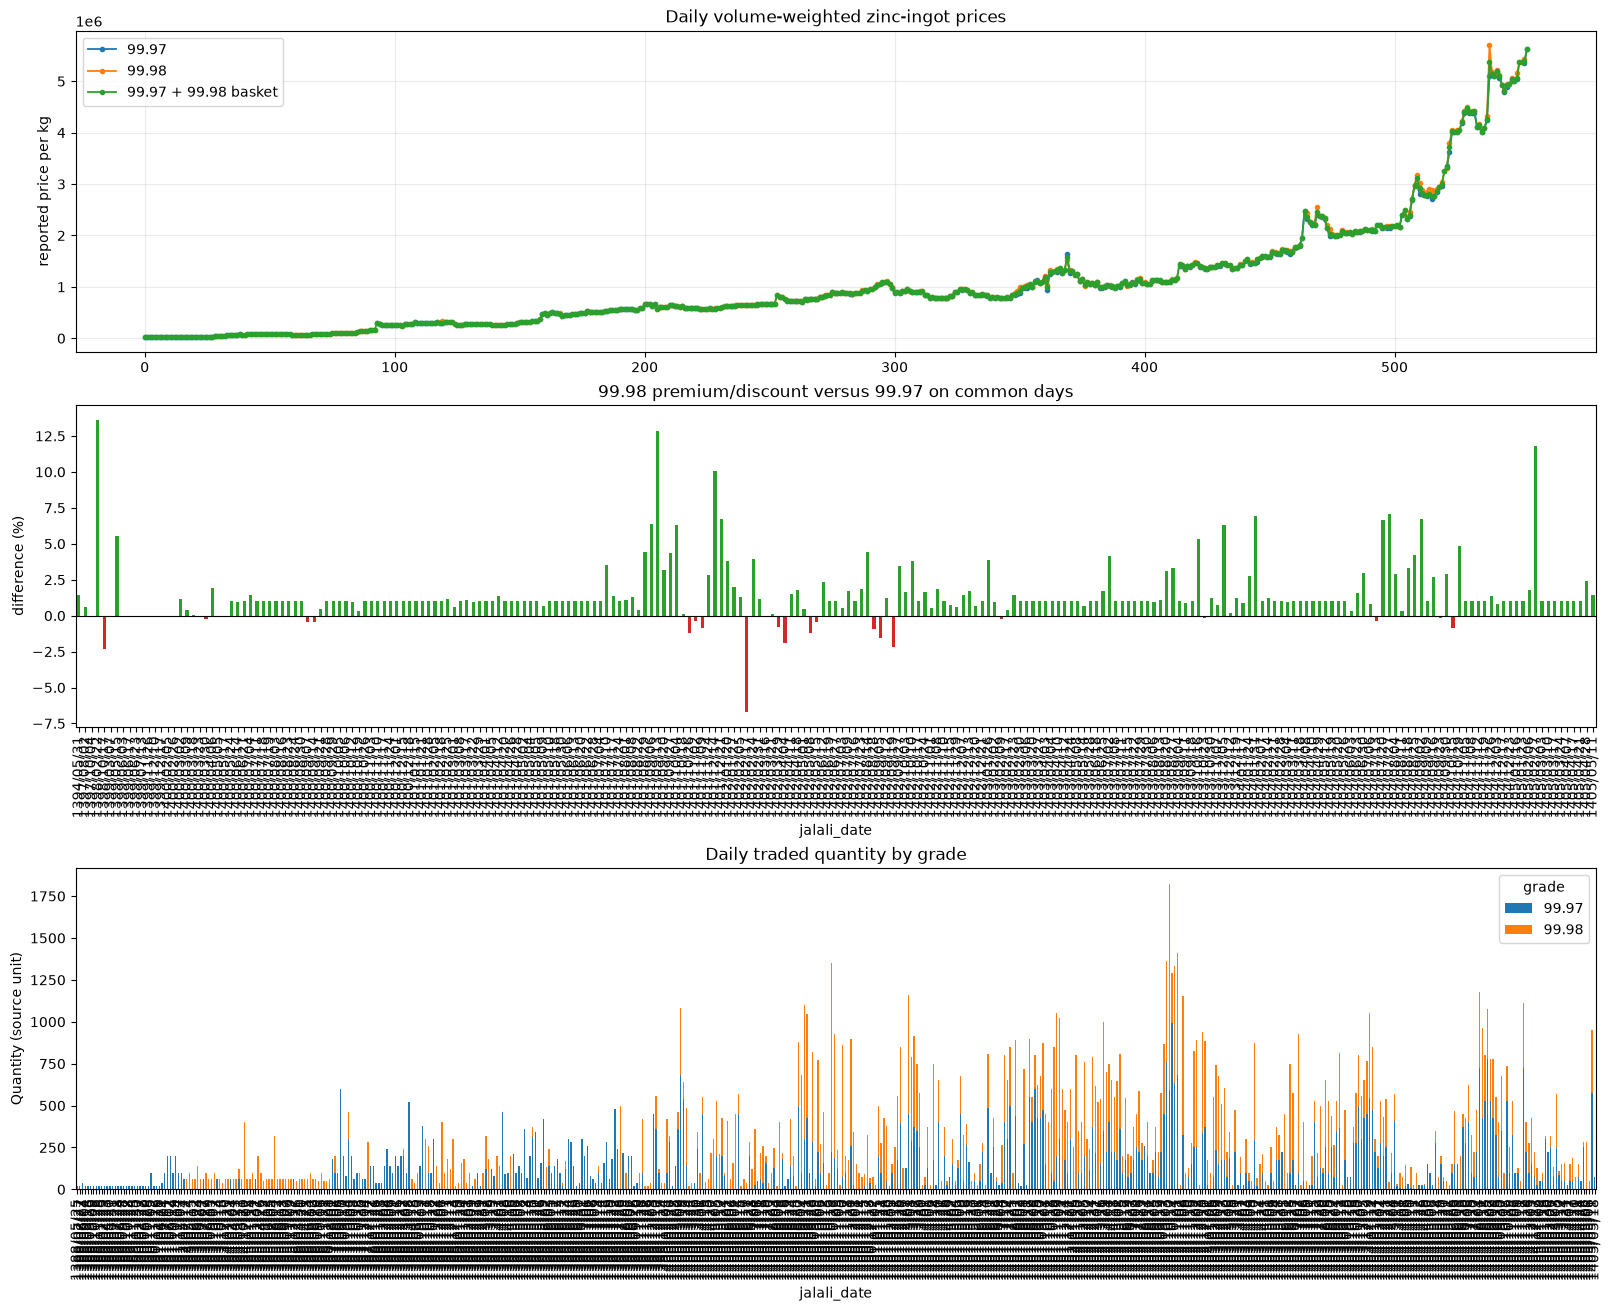

,1388/05/25,1388/07/27,1388/08/27,1388/09/04,1388/09/18,1388/09/25,1388/10/09,1388/10/26,1388/11/28,1389/01/25,1389/02/29,1389/04/23,1389/05/20,1389/06/31,1389/07/21,1389/07/28,1389/08/24,1389/09/28,1389/10/27,1389/10/28,1389/11/24,1389/11/25,1390/01/30,1390/02/27,1390/03/22,1390/06/20,1390/10/28,1390/11/05,1390/11/12,1390/11/26,1391/02/18,1391/06/21,1391/07/04,1391/07/11,1391/08/02,1391/09/14,1391/10/19,1391/11/04,1391/12/07,1392/05/14,1392/07/17,1393/05/14,1393/05/15,1393/06/02,1393/06/23,1393/06/24,1393/07/07,1393/07/27,1393/08/19,1393/09/05,...,1405/03/05,1405/03/09,1405/03/10,1405/03/11,1405/03/12,1405/03/13,1405/03/16,1405/03/17,1405/03/18,1405/03/19,1405/03/20,1405/03/23,1405/03/24,1405/03/25,1405/03/26,1405/03/27,1405/03/30,1405/03/31,1405/04/01,1405/04/02,1405/04/06,1405/04/07,1405/04/08,1405/04/09,1405/04/10,1405/04/16,1405/04/17,1405/04/20,1405/04/21,1405/04/22,1405/04/23,1405/04/24,1405/04/27,1405/04/28,1405/04/29,1405/04/30,1405/04/31,1405/05/03,1405/05/04,1405/05/05,1405/05/06,1405/05/07,1405/05/10,1405/05/11,1405/05/12,1405/05/14,1405/05/17,1405/05/18,1405/05/19,1405/05/20
99.97,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
99.98,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0,1,1,1,...,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0
basket,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,1,0,0,1,0,1,0,0,0,0,0,1,1,0,0,1,0,0,0,1,0,0
certificate,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


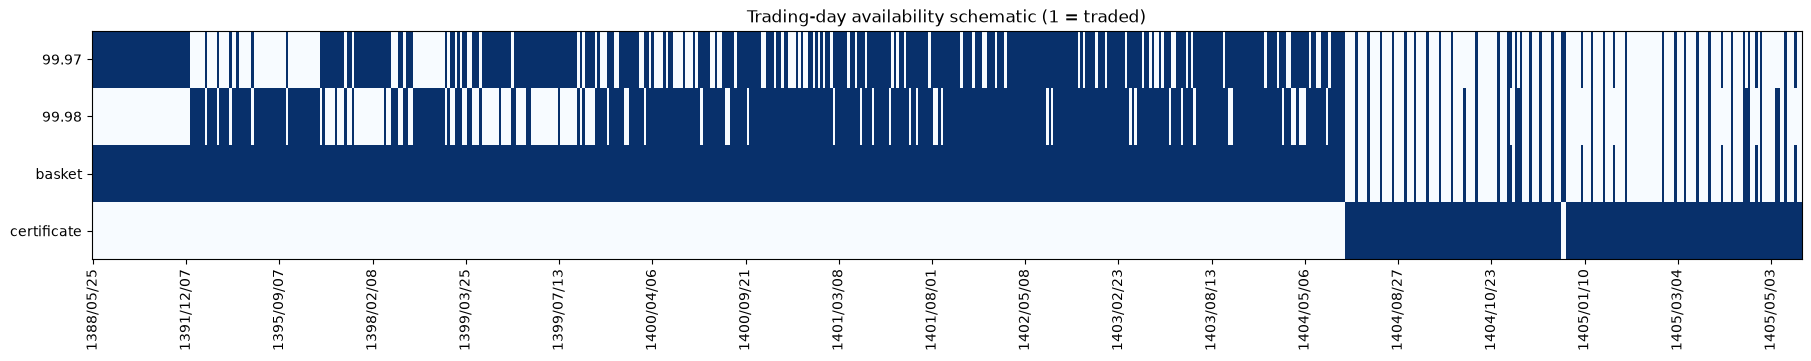

In [12]:
import matplotlib.pyplot as plt

plot_prices = price_wide.reindex(columns=FOCUS_GRADES).copy()
plot_prices["99.97 + 99.98 basket"] = daily_basket_price.set_index("jalali_date")["basket_price_per_kg"]
plot_prices = plot_prices.sort_index()
x = np.arange(len(plot_prices))

fig, axes = plt.subplots(3, 1, figsize=(16, 13), constrained_layout=True)
for column in plot_prices.columns:
    axes[0].plot(x, plot_prices[column], marker="o", markersize=3, linewidth=1.3, label=column)
axes[0].set_title("Daily volume-weighted zinc-ingot prices")
axes[0].set_ylabel("reported price per kg")
axes[0].grid(alpha=0.25)
axes[0].legend()

difference_plot = both_grade_price_comparison.set_index("jalali_date")["difference_pct_vs_97"]
difference_plot.plot(kind="bar", ax=axes[1], color=np.where(difference_plot >= 0, "tab:green", "tab:red"))
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("99.98 premium/discount versus 99.97 on common days")
axes[1].set_ylabel("difference (%)")
axes[1].tick_params(axis="x", rotation=90)

quantity_wide.reindex(columns=FOCUS_GRADES).plot(kind="bar", stacked=True, ax=axes[2])
axes[2].set_title("Daily traded quantity by grade")
axes[2].set_ylabel("Quantity (source unit)")
axes[2].tick_params(axis="x", rotation=90)
plt.show()

# Daily activity map across the basket date range
activity_dates = sorted(basket_days | certificate_days)
activity_matrix = pd.DataFrame(
    [
        [date in days_97 for date in activity_dates],
        [date in days_98 for date in activity_dates],
        [date in basket_days for date in activity_dates],
        [date in certificate_days for date in activity_dates],
    ],
    index=["99.97", "99.98", "basket", "certificate"],
    columns=activity_dates,
    dtype=int,
)
display(activity_matrix)

fig, ax = plt.subplots(figsize=(18, 3.5), constrained_layout=True)
ax.imshow(activity_matrix, aspect="auto", interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
ax.set_yticks(range(len(activity_matrix.index)), labels=activity_matrix.index)
tick_step = max(1, len(activity_dates) // 18)
tick_positions = np.arange(0, len(activity_dates), tick_step)
ax.set_xticks(tick_positions, labels=[activity_dates[i] for i in tick_positions], rotation=90)
ax.set_title("Trading-day availability schematic (1 = traded)")
plt.show()

## Standard market dashboard

This governed, read-only section uses the same presentation contract across commodity projects:
source coverage, physical and certificate activity, separate price panels, physical-goods
composition, and validated processed bubbles. It never writes raw data or constructs a missing
bubble. For Zinc, product comparability still follows the project-specific workflow.

,source_records,positive_trade_records,trading_days,first_date,last_date
market,,,,,
physical,6235,3462,760,1387/07/28,1405/05/18
certificate,256,184,184,1404/07/28,1405/05/22


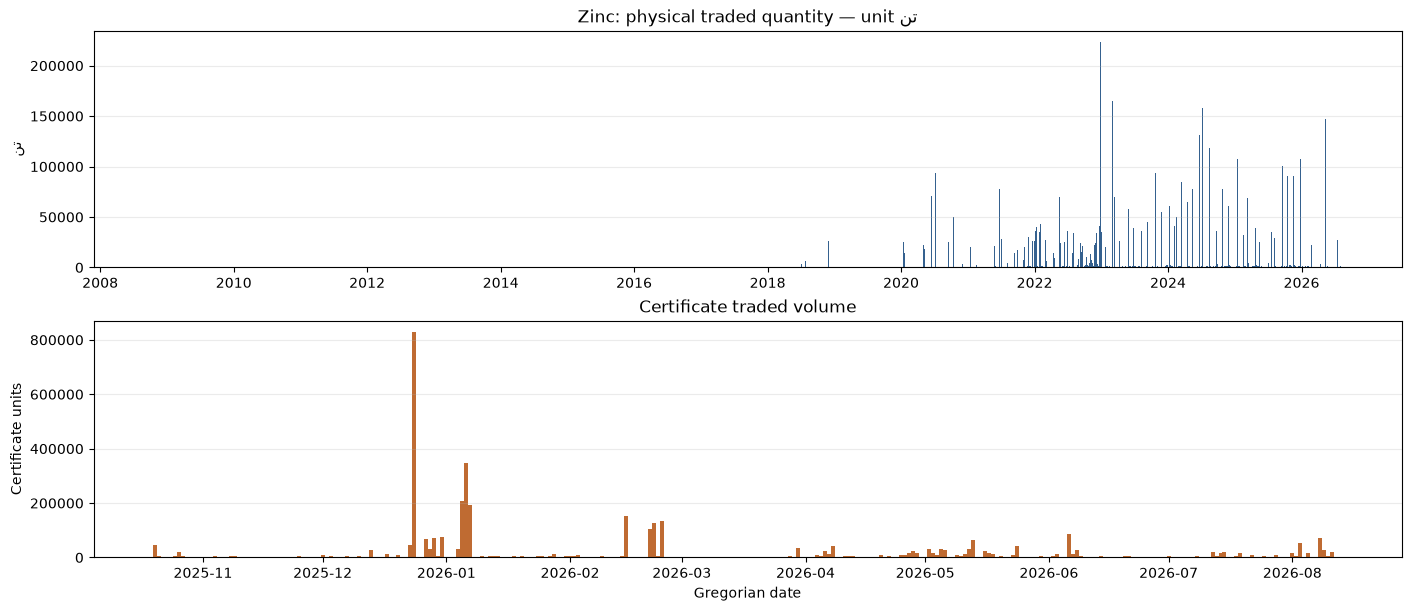

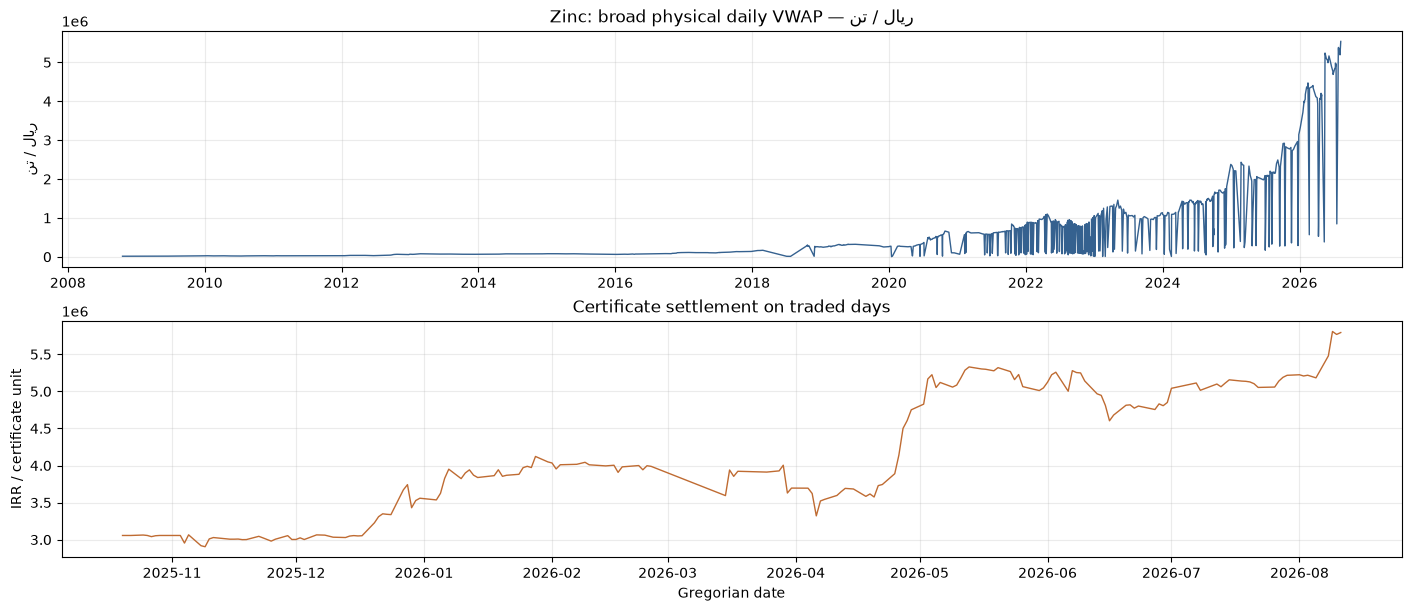

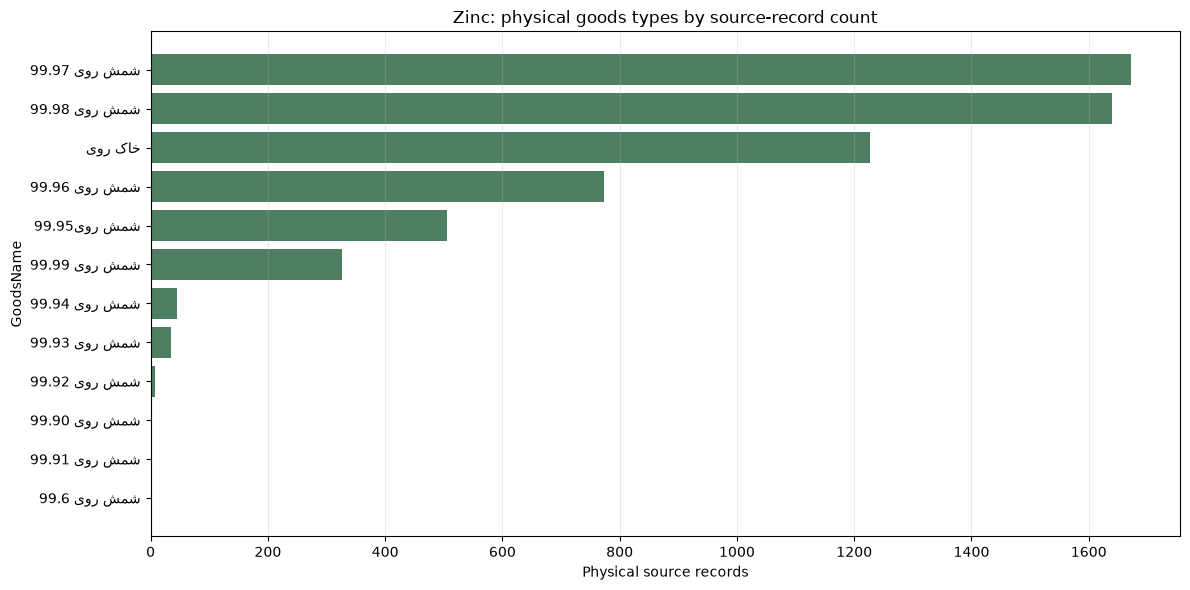

Distinct physical GoodsName labels: 12; records counted: 6,235


,goods_name,record_count,share_pct
0,شمش روی 99.97,1672,26.816359
1,شمش روی 99.98,1639,26.287089
2,خاک روی,1227,19.679230
3,شمش روی 99.96,774,12.413793
4,شمش روی99.95,506,8.115477
5,شمش روی 99.99,326,5.228549
6,شمش روی 99.94,45,0.721732
7,شمش روی 99.93,35,0.561347
8,شمش روی 99.92,7,0.112269
9,شمش روی 99.90,2,0.032077


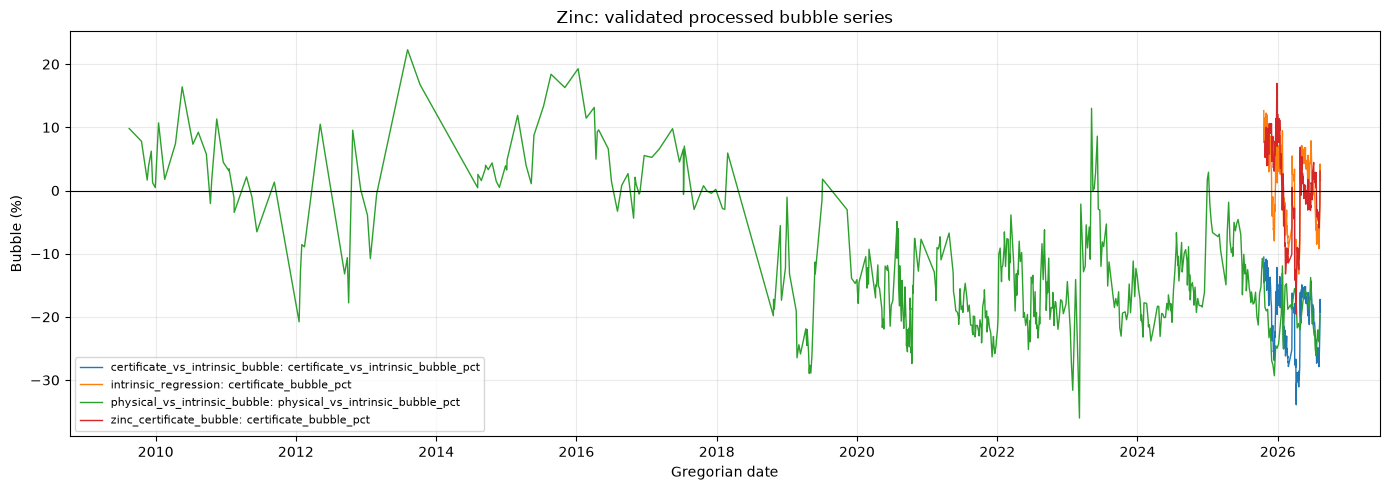

In [13]:
from pathlib import Path
import sys

def locate_workspace(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "commodity" / "zinc").exists() and (candidate / "shared").exists():
            return candidate
    raise FileNotFoundError("Could not locate workspace root")

WORKSPACE_ROOT = locate_workspace()
if str(WORKSPACE_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_ROOT))

from shared.notebook_tools.commodity_dashboard import (
    goods_type_counts,
    load_markets,
    market_summary,
    plot_available_bubbles,
    plot_goods_type_counts,
    plot_market_prices,
    plot_trade_activity,
)

PROJECT_DIR = WORKSPACE_ROOT / "commodity" / "zinc"
physical_dashboard, certificate_dashboard = load_markets(
    PROJECT_DIR, "zinc", physical_filename=None
)
display(market_summary(physical_dashboard, certificate_dashboard))
plot_trade_activity(physical_dashboard, certificate_dashboard, "Zinc")
plot_market_prices(physical_dashboard, certificate_dashboard, "Zinc")
goods_count_table = plot_goods_type_counts(physical_dashboard, "Zinc", top_n=30)
display(goods_count_table)
bubble_series_plotted = plot_available_bubbles(PROJECT_DIR, "Zinc")